<a href="https://www.kaggle.com/code/sonawanelalitsunil/pokemon-detective-unmask-team-rocket-ml-98?scriptVersionId=230642637" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pokmon-detective-challenge/pokemon_team_rocket_dataset.csv


## Pokemon Detective: Unmask Team Rocket

## Uncover the secret plans of Team Rocket as you analyze clues, track their movements, and expose their hidden operations in the Pokémon world! 🕵️‍♂️🔥

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/pokmon-detective-challenge/pokemon_team_rocket_dataset.csv')

In [3]:
df.head()

,ID,Age,City,Economic Status,Profession,Most Used Pokemon Type,Average Pokemon Level,Criminal Record,PokéBall Usage,Win Ratio,Number of Gym Badges,Is Pokemon Champion,Battle Strategy,Number of Migrations,Rare Item Holder,Debt to Kanto,Charity Participation,Team Rocket
0,0,27,Pewter City,Middle,Fisherman,Rock,50,0,DuskBall,51,1,False,Unpredictable,25,False,24511,True,No
1,1,55,Viridian City,Middle,PokéMart Seller,Grass,35,1,HealBall,53,2,False,Unpredictable,19,False,177516,True,Yes
2,2,14,Pallet Town,High,Police Officer,Poison,96,0,NetBall,76,5,False,Aggressive,18,False,85695,True,No
3,3,41,Cerulean City,Middle,Gym Leader Assistant,Dragon,23,0,UltraBall,27,0,False,Defensive,10,False,39739,True,No
4,4,15,Pallet Town,Middle,Gym Leader Assistant,Ground,16,1,HealBall,51,1,False,Aggressive,17,True,126923,False,Yes


In [4]:
df.tail()

,ID,Age,City,Economic Status,Profession,Most Used Pokemon Type,Average Pokemon Level,Criminal Record,PokéBall Usage,Win Ratio,Number of Gym Badges,Is Pokemon Champion,Battle Strategy,Number of Migrations,Rare Item Holder,Debt to Kanto,Charity Participation,Team Rocket
4995,4995,36,Viridian City,Middle,Researcher,Rock,91,0,LuxuryBall,53,5,False,Defensive,5,False,70192,True,NaN
4996,4996,17,Vermilion City,Middle,Gym Leader Assistant,Dragon,23,0,PokéBall,40,0,False,Defensive,1,False,43208,True,NaN
4997,4997,67,Fuchsia City,High,Elite Trainer,Dark,13,0,UltraBall,36,0,False,Defensive,25,False,47794,True,NaN
4998,4998,43,Viridian City,Middle,Daycare Worker,Poison,48,0,MasterBall,51,4,False,Defensive,4,False,10995,True,NaN
4999,4999,44,Fuchsia City,Middle,Nurse,Flying,10,0,MasterBall,22,0,False,Defensive,3,False,42566,True,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ID                      5000 non-null   int64 
 1   Age                     5000 non-null   int64 
 2   City                    5000 non-null   object
 3   Economic Status         5000 non-null   object
 4   Profession              5000 non-null   object
 5   Most Used Pokemon Type  5000 non-null   object
 6   Average Pokemon Level   5000 non-null   int64 
 7   Criminal Record         5000 non-null   int64 
 8   PokéBall Usage          5000 non-null   object
 9   Win Ratio               5000 non-null   int64 
 10  Number of Gym Badges    5000 non-null   int64 
 11  Is Pokemon Champion     5000 non-null   bool  
 12  Battle Strategy         5000 non-null   object
 13  Number of Migrations    5000 non-null   int64 
 14  Rare Item Holder        5000 non-null   bool  
 15  Debt

In [6]:
df.describe()

,ID,Age,Average Pokemon Level,Criminal Record,Win Ratio,Number of Gym Badges,Number of Migrations,Debt to Kanto
count,5000.000000,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2499.500000,40.30080,52.256400,0.08300,53.190800,2.231200,13.125600,75527.163400
std,1443.520003,17.46132,27.572209,0.27591,18.940563,1.987898,7.790684,76820.989625
min,0.000000,10.00000,5.000000,0.00000,20.000000,0.000000,0.000000,37.000000
25%,1249.750000,25.00000,28.000000,0.00000,37.000000,1.000000,6.000000,29371.250000
50%,2499.500000,41.00000,52.500000,0.00000,53.000000,2.000000,13.000000,58224.000000
75%,3749.250000,55.00000,76.000000,0.00000,69.000000,4.000000,20.000000,86782.000000
max,4999.000000,70.00000,100.000000,1.00000,90.000000,8.000000,30.000000,399007.000000


In [7]:
df.isnull().sum()

ID                           0
Age                          0
City                         0
Economic Status              0
Profession                   0
Most Used Pokemon Type       0
Average Pokemon Level        0
Criminal Record              0
PokéBall Usage               0
Win Ratio                    0
Number of Gym Badges         0
Is Pokemon Champion          0
Battle Strategy              0
Number of Migrations         0
Rare Item Holder             0
Debt to Kanto                0
Charity Participation        0
Team Rocket               1000
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(5000, 18)

In [10]:
df.dtypes

ID                         int64
Age                        int64
City                      object
Economic Status           object
Profession                object
Most Used Pokemon Type    object
Average Pokemon Level      int64
Criminal Record            int64
PokéBall Usage            object
Win Ratio                  int64
Number of Gym Badges       int64
Is Pokemon Champion         bool
Battle Strategy           object
Number of Migrations       int64
Rare Item Holder            bool
Debt to Kanto              int64
Charity Participation       bool
Team Rocket               object
dtype: object

In [11]:
df.columns

Index(['ID', 'Age', 'City', 'Economic Status', 'Profession',
       'Most Used Pokemon Type', 'Average Pokemon Level', 'Criminal Record',
       'PokéBall Usage', 'Win Ratio', 'Number of Gym Badges',
       'Is Pokemon Champion', 'Battle Strategy', 'Number of Migrations',
       'Rare Item Holder', 'Debt to Kanto', 'Charity Participation',
       'Team Rocket'],
      dtype='object')

## Data visualizations

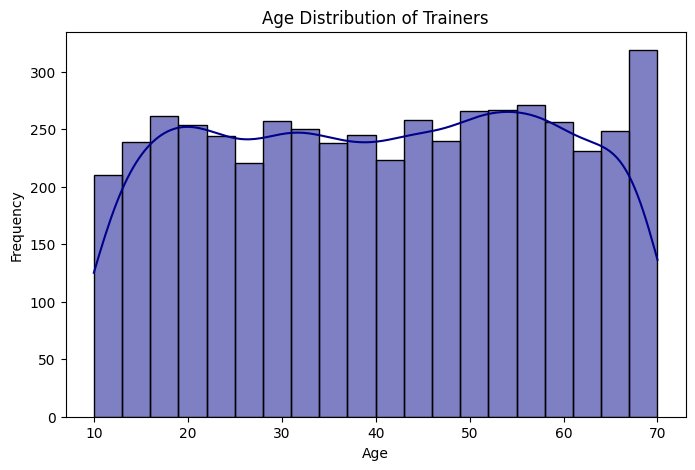

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='darkblue')
plt.title('Age Distribution of Trainers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

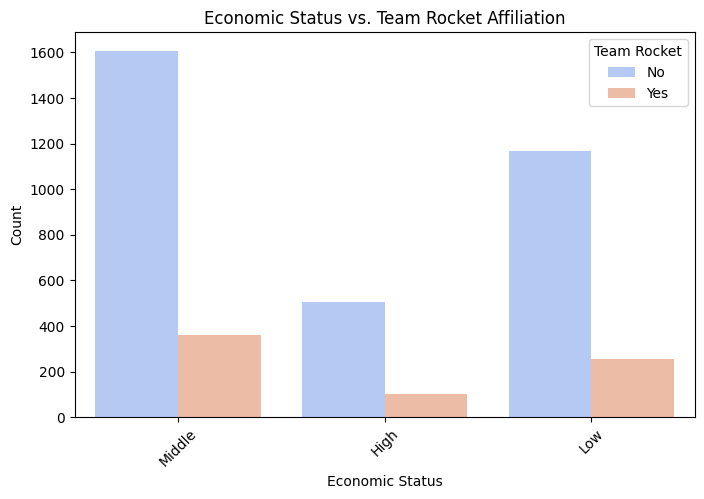

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Economic Status', hue='Team Rocket', data=df, palette='coolwarm')
plt.title('Economic Status vs. Team Rocket Affiliation')
plt.xlabel('Economic Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

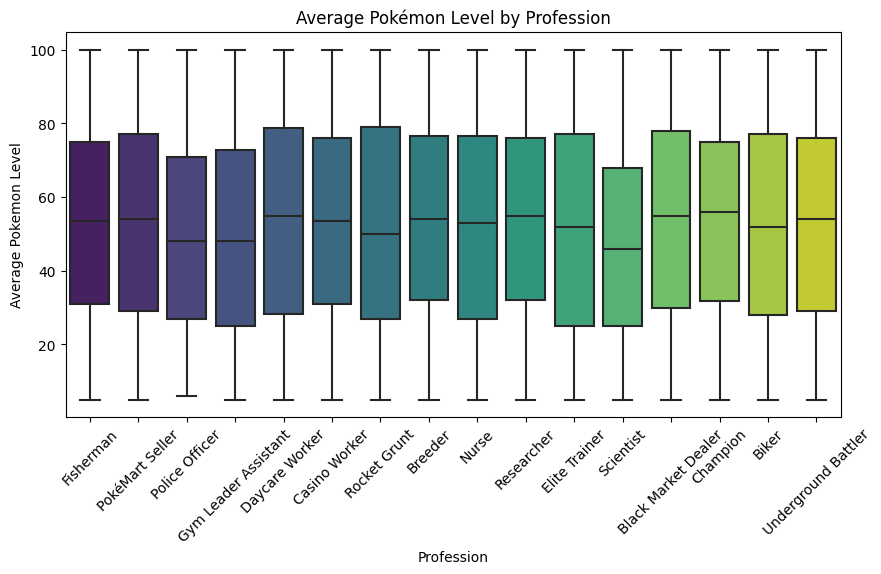

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Profession', y='Average Pokemon Level', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Average Pokémon Level by Profession')
plt.show()

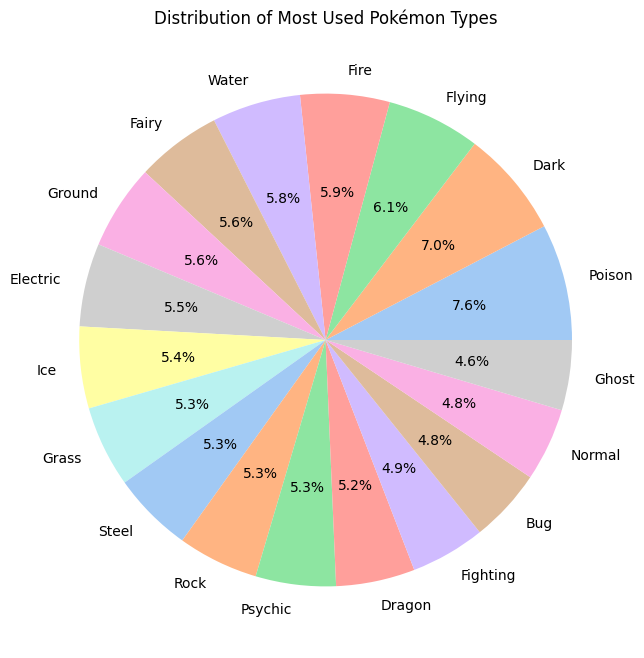

In [15]:
plt.figure(figsize=(8, 8))
df['Most Used Pokemon Type'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title('Distribution of Most Used Pokémon Types')
plt.ylabel('')
plt.show()

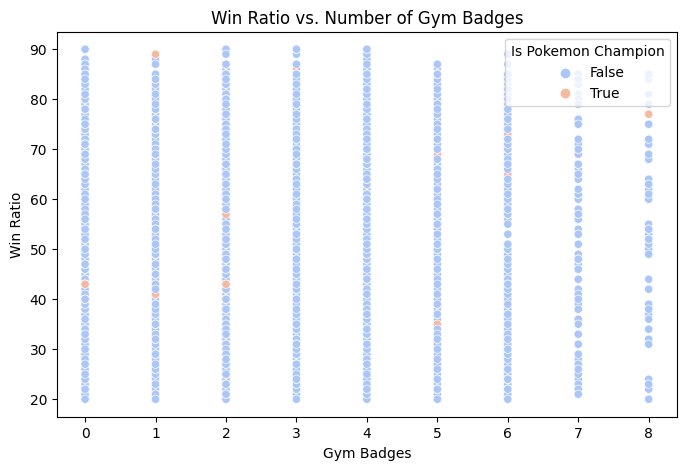

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Number of Gym Badges', y='Win Ratio', hue='Is Pokemon Champion', data=df, palette='coolwarm')
plt.title('Win Ratio vs. Number of Gym Badges')
plt.xlabel('Gym Badges')
plt.ylabel('Win Ratio')
plt.show()

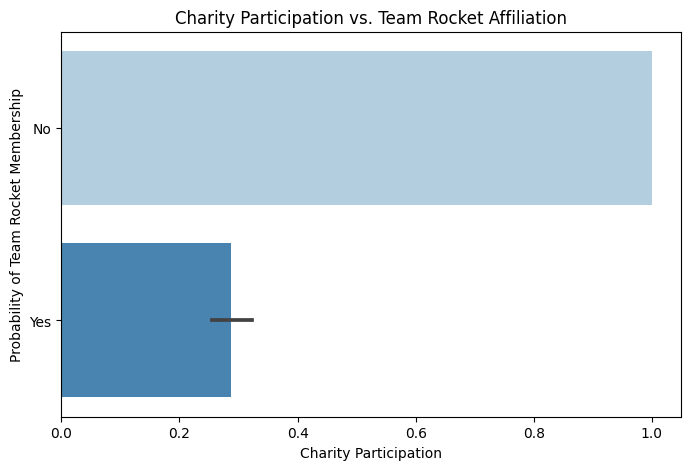

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Charity Participation', y='Team Rocket', data=df, palette='Blues')
plt.title('Charity Participation vs. Team Rocket Affiliation')
plt.xlabel('Charity Participation')
plt.ylabel('Probability of Team Rocket Membership')
plt.show()

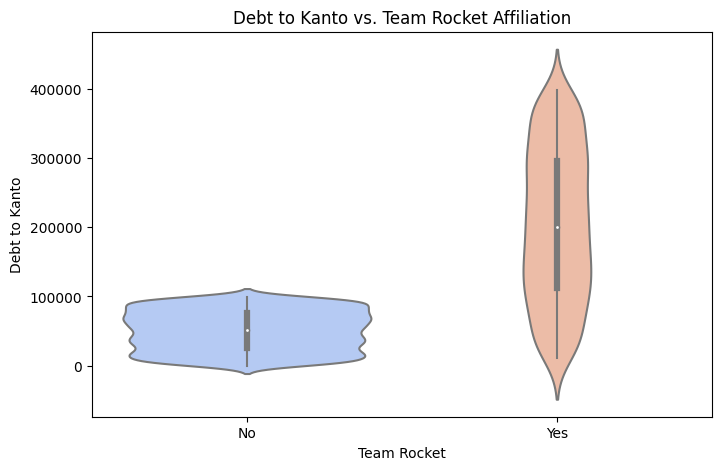

In [18]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Team Rocket', y='Debt to Kanto', data=df, palette='coolwarm')
plt.title('Debt to Kanto vs. Team Rocket Affiliation')
plt.show()

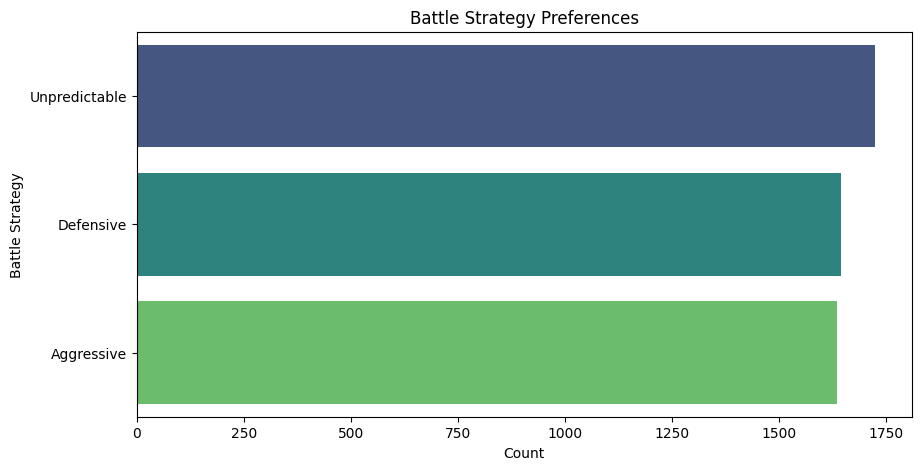

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(y='Battle Strategy', data=df, palette='viridis', order=df['Battle Strategy'].value_counts().index)
plt.title('Battle Strategy Preferences')
plt.xlabel('Count')
plt.ylabel('Battle Strategy')
plt.show()

## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [21]:
# Drop ID column if not relevant
df.drop(columns=['ID'], inplace=True)

In [22]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [23]:
# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [24]:
# Define features and target
target = 'Is Pokemon Champion'  # Update with correct target
X = df.drop(columns=[target])
y = df[target]


In [25]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [27]:
# Define ML Models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC()
}

In [28]:
# Train and Evaluate Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'--- {name} ---')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(classification_report(y_test, y_pred))
    print('\n' + '-'*40 + '\n')


--- Logistic Regression ---
Accuracy: 0.9810
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       982
        True       0.00      0.00      0.00        18

    accuracy                           0.98      1000
   macro avg       0.49      0.50      0.50      1000
weighted avg       0.96      0.98      0.97      1000


----------------------------------------

--- Random Forest ---
Accuracy: 0.9820
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       982
        True       0.00      0.00      0.00        18

    accuracy                           0.98      1000
   macro avg       0.49      0.50      0.50      1000
weighted avg       0.96      0.98      0.97      1000


----------------------------------------

--- Gradient Boosting ---
Accuracy: 0.9790
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       982
        True       0.00 

In [29]:
# Train and Evaluate Models
accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    accuracies[name] = accuracy
    print(f'--- {name} ---')
    print(f'Accuracy: {accuracy:.2f}%')
    print(classification_report(y_test, y_pred))
    print('\n' + '-'*40 + '\n')

--- Logistic Regression ---
Accuracy: 98.10%
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       982
        True       0.00      0.00      0.00        18

    accuracy                           0.98      1000
   macro avg       0.49      0.50      0.50      1000
weighted avg       0.96      0.98      0.97      1000


----------------------------------------

--- Random Forest ---
Accuracy: 98.20%
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       982
        True       0.00      0.00      0.00        18

    accuracy                           0.98      1000
   macro avg       0.49      0.50      0.50      1000
weighted avg       0.96      0.98      0.97      1000


----------------------------------------

--- Gradient Boosting ---
Accuracy: 97.90%
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       982
        True       0.00 

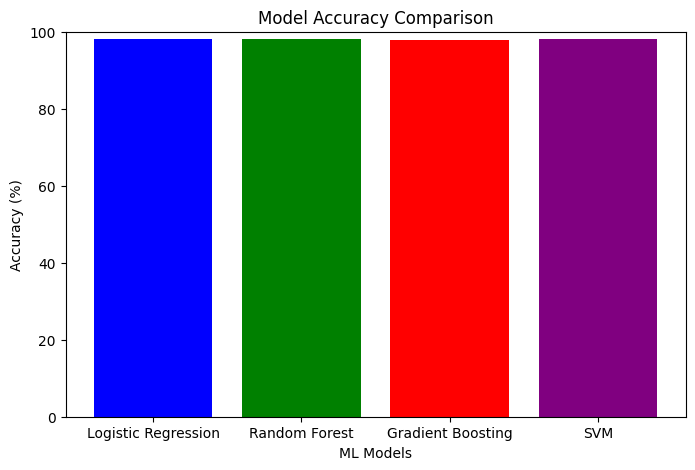

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'green', 'red', 'purple'])
plt.xlabel('ML Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)
plt.show()

## Thank you!!!!...pls upvote!!!